## Flight Price Prediction Model

#### Objective

Build a regression model to predict flight prices using travel information such as:

- Distance
- Travel Time
- Flight Type
- Agency
- Origin
- Destination
- Month

Models Evaluated:

1. Linear Regression
2. Random Forest Regressor
3. XGBoost Regressor

Evaluation Metrics:

- MAE
- RMSE
- R² Score

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import os

import warnings
warnings.filterwarnings("ignore")

#### Load Processed Dataset

In [2]:
flight_user = pd.read_csv(
    "../data/processed/flight_user.csv"
)

print(
    "Shape:",
    flight_user.shape
)

flight_user.head()

Shape: (271888, 19)


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,year,month,day,day_of_week,code,company,name,gender,age
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,2019,9,26,Thursday,0,4You,Roy Braun,male,21
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,2019,9,30,Monday,0,4You,Roy Braun,male,21
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,2019,10,3,Thursday,0,4You,Roy Braun,male,21
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,2019,10,4,Friday,0,4You,Roy Braun,male,21
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,2019,10,10,Thursday,0,4You,Roy Braun,male,21


#### Dataset Information

In [3]:
flight_user.info()

flight_user.describe()

flight_user.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 19 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   travelCode   271888 non-null  int64  
 1   userCode     271888 non-null  int64  
 2   from         271888 non-null  object 
 3   to           271888 non-null  object 
 4   flightType   271888 non-null  object 
 5   price        271888 non-null  float64
 6   time         271888 non-null  float64
 7   distance     271888 non-null  float64
 8   agency       271888 non-null  object 
 9   date         271888 non-null  object 
 10  year         271888 non-null  int64  
 11  month        271888 non-null  int64  
 12  day          271888 non-null  int64  
 13  day_of_week  271888 non-null  object 
 14  code         271888 non-null  int64  
 15  company      271888 non-null  object 
 16  name         271888 non-null  object 
 17  gender       271888 non-null  object 
 18  age          271888 non-

travelCode     135944
userCode         1335
from                9
to                  9
flightType          3
price             490
time               33
distance           35
agency              3
date              999
year                5
month              12
day                31
day_of_week         5
code             1335
company             5
name             1333
gender              3
age                45
dtype: int64

#### Select Features and Target Variable

In [4]:
feature_columns = [
    "distance",
    "time",
    "flightType",
    "agency",
    "from",
    "to",
    "month"
]

target_column = "price"

X = flight_user[
    feature_columns
]

y = flight_user[
    target_column
]

print(
    "Feature Shape:",
    X.shape
)

print(
    "Target Shape:",
    y.shape
)

Feature Shape: (271888, 7)
Target Shape: (271888,)


#### Encode Categorical Variables

In [5]:
categorical_cols = [
    "flightType",
    "agency",
    "from",
    "to"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print(
    "Encoded Shape:",
    X.shape
)

X.head()

Encoded Shape: (271888, 23)


,distance,time,month,flightType_firstClass,flightType_premium,agency_FlyingDrops,agency_Rainbow,from_Brasilia (DF),from_Campo Grande (MS),from_Florianopolis (SC),...,from_Salvador (BH),from_Sao Paulo (SP),to_Brasilia (DF),to_Campo Grande (MS),to_Florianopolis (SC),to_Natal (RN),to_Recife (PE),to_Rio de Janeiro (RJ),to_Salvador (BH),to_Sao Paulo (SP)
0,676.53,1.76,9,True,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,676.53,1.76,9,True,False,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,637.56,1.66,10,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
3,637.56,1.66,10,True,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,830.86,2.16,10,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


#### Save Deployment Feature Structure

The trained model expects the exact feature structure created after one-hot encoding.

The feature columns are saved and later reused in the Flask API during inference.

In [6]:
os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    X.columns.tolist(),
    "../models/flight_columns.pkl"
)

print(
    "Flight Feature Columns Saved Successfully"
)

Flight Feature Columns Saved Successfully


#### Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    "Train Shape:",
    X_train.shape
)

print(
    "Test Shape:",
    X_test.shape
)

Train Shape: (217510, 23)
Test Shape: (54378, 23)


#### Linear Regression Model

In [8]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, pred_lr)
)

r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression Results")
print("-" * 40)
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression Results
----------------------------------------
MAE : 81.32118063343705
RMSE: 103.15216298774865
R2  : 0.919249958062951


#### Random Forest Regressor

In [9]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, pred_rf)
)

r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Results")
print("-" * 40)
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest Results
----------------------------------------
MAE : 2.87431928434838e-12
RMSE: 4.131941879715988e-12
R2  : 1.0


#### XGBoost Regressor

In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, pred_xgb)
)

r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost Results")
print("-" * 40)
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

XGBoost Results
----------------------------------------
MAE : 11.725380887951909
RMSE: 15.609967461046324
R2  : 0.9981507736466858


#### Model Comparison

In [11]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
1,Random Forest,2.874319e-12,4.131942e-12,1.000000
2,XGBoost,1.172538e+01,1.560997e+01,0.998151
0,Linear Regression,8.132118e+01,1.031522e+02,0.919250


#### Feature Importance (Random Forest)

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
3,flightType_firstClass,0.296597
1,time,0.251551
0,distance,0.230820
4,flightType_premium,0.076931
9,from_Florianopolis (SC),0.051412
17,to_Florianopolis (SC),0.018754
14,from_Sao Paulo (SP),0.014580
7,from_Brasilia (DF),0.013291
22,to_Sao Paulo (SP),0.006796
18,to_Natal (RN),0.006589


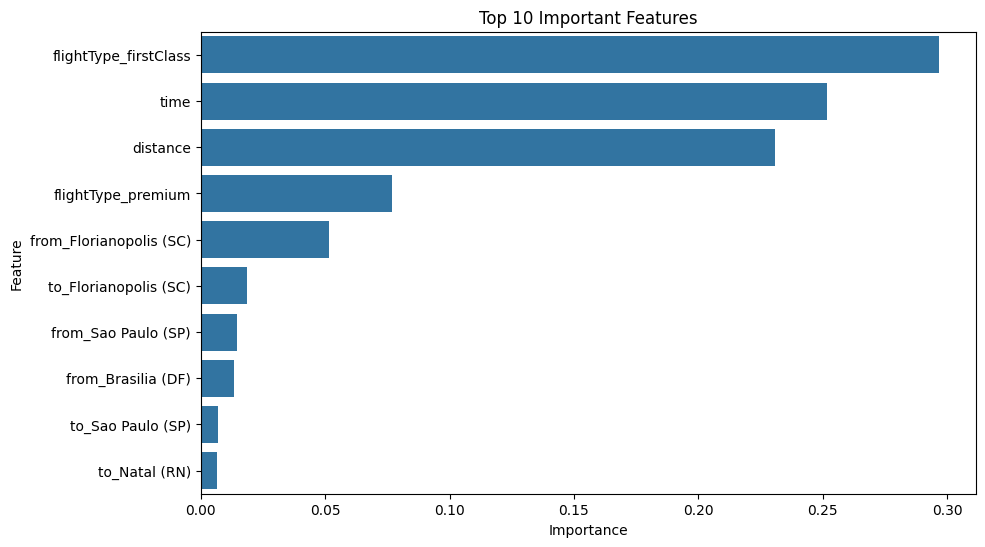

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

#### Save Deployment Artifacts

In [14]:
os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    rf,
    "../models/flight_price_model.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "../models/flight_columns.pkl"
)

print(
    "Flight Price Model Saved Successfully"
)

print(
    "Flight Feature Columns Saved Successfully"
)

Flight Price Model Saved Successfully
Flight Feature Columns Saved Successfully


## Deployment Artifacts

### Saved Files

```text
../models/flight_price_model.pkl
../models/flight_columns.pkl
```

### Purpose

- flight_price_model.pkl stores the trained Random Forest model.
- flight_columns.pkl stores the exact encoded feature structure used during training.

These artifacts are required for Flask API deployment and inference consistency.

#### Output

```text
../models/flight_price_model.pkl

../models/flight_columns.pkl
```